# 03 — RQ1: document-level sentiment classification

**RQ1.** How well do classical models classify review-level sentiment, how does class imbalance affect them, and what is the trade-off between predictive performance and interpretability?

This notebook compares a majority-class baseline against Multinomial Naive Bayes, Logistic Regression and LightGBM gradient boosting on TF-IDF features, under both the binary and ternary framings, **with and without imbalance handling**. The headline metrics are **macro-F1 and per-class recall** — accuracy is reported only for reference, because (as the EDA showed) a trivial always-positive model already scores ~69% accuracy.

> Runtime note: the two gradient-boosting configurations per framing are the slow part (~1-2 min each). Naive Bayes and Logistic Regression fit in well under a second. Run top-to-bottom.

In [1]:
import sys
from pathlib import Path

# Resolve project root whether launched from the repo root or notebooks/.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
RANDOM_STATE = 42

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
MODELS_DIR = PROJECT_ROOT / 'models'
for d in (PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

NAVY, BLUE, ORANGE = '#1E3A6E', '#5B8DBF', '#D97757'

In [2]:
from src import dataset, features, models, evaluation

df = pd.read_parquet(PROC_DIR / 'reviews_clean.parquet')
df = df[df['clean_text'].str.len() > 0].copy()   # drop empty-after-cleaning reviews
train_df, test_df = dataset.chronological_split(df, test_size=0.2, by_category=True)
print(f'train {len(train_df):,} | test {len(test_df):,}')

train 69,949 | test 17,489


## 1. A reusable run helper

Each configuration fits on the (optionally resampled) training split and is scored on the held-out test split.

In [3]:
def run_config(Xtr, ytr, Xte, yte, labels, model, resample=None):
    if resample:
        Xtr, ytr = models.resample_balanced(Xtr, ytr, strategy=resample)
    model.fit(Xtr, ytr)
    res = evaluation.evaluate_model(yte, model.predict(Xte), labels=labels)
    res['_model'] = model
    return res

def run_all(framing, col, labels):
    tr, te = dataset.prepare_task(train_df, test_df, col)
    print(f'[{framing}] train {len(tr):,} test {len(te):,} | {tr[col].value_counts().to_dict()}')
    Xtr, Xte, vec = features.fit_transform_split(
        tr['clean_text'], te['clean_text'], ngram_range=(1, 2), max_features=20000, min_df=5)
    ytr, yte = tr[col].values, te[col].values
    res = {}
    res['majority_baseline']     = run_config(Xtr, ytr, Xte, yte, labels, models.get_majority_baseline())
    # --- no imbalance handling: watch the minority class collapse ---
    res['naive_bayes']           = run_config(Xtr, ytr, Xte, yte, labels, models.get_naive_bayes())
    res['logreg']                = run_config(Xtr, ytr, Xte, yte, labels, models.get_logistic_regression(class_weight=None))
    res['gboost']                = run_config(Xtr, ytr, Xte, yte, labels, models.get_gradient_boosting(class_weight=None))
    # --- with imbalance handling ---
    res['naive_bayes_resampled'] = run_config(Xtr, ytr, Xte, yte, labels, models.get_naive_bayes(), resample='undersample')
    res['logreg_balanced']       = run_config(Xtr, ytr, Xte, yte, labels, models.get_logistic_regression(class_weight='balanced'))
    res['gboost_balanced']       = run_config(Xtr, ytr, Xte, yte, labels, models.get_gradient_boosting(class_weight='balanced'))
    return res, te, vec

## 2. Binary framing

Negative (1-2★) vs positive (4-5★), 3★ dropped.

In [4]:
labels_b = ['positive', 'negative']
results_b, te_b, vec_b = run_all('binary', 'sentiment_binary', labels_b)
cmp_b = evaluation.compare_models(results_b)
cmp_b.to_csv(TABLES_DIR / 'rq1_binary_comparison.csv')
evaluation.results_to_latex(cmp_b, TABLES_DIR / 'rq1_binary_comparison.tex',
    caption='RQ1 model comparison, binary framing.', label='tab:rq1_binary')
cmp_b

[binary] train 64,429 test 16,241 | {'positive': 51828, 'negative': 12601}


,accuracy,f1_macro,f1_weighted,recall_macro,recall_positive,recall_negative
model,,,,,,
majority_baseline,0.6886,0.4078,0.5616,0.5000,1.0000,0.0000
naive_bayes,0.8397,0.7871,0.8270,0.7604,0.9707,0.5502
logreg,0.8711,0.8378,0.8655,0.8165,0.9612,0.6718
gboost,0.8569,0.8172,0.8493,0.7941,0.9607,0.6275
naive_bayes_resampled,0.8596,0.8454,0.8631,0.8689,0.8442,0.8936
logreg_balanced,0.8849,0.8698,0.8865,0.8822,0.8893,0.8750
gboost_balanced,0.8503,0.8343,0.8537,0.8549,0.8426,0.8671


**Reading.** The majority baseline reaches ~69% accuracy but macro-F1 ~0.41 and **zero recall on the negative class** — it never predicts negative. Without imbalance handling, all three models inherit a version of this: Naive Bayes recovers only about half the negatives. Switching on `class_weight='balanced'` (LR, GB) or undersampling (NB) lifts negative recall to ~0.87-0.89 with little or no accuracy cost. **Logistic Regression with balanced weights is the best overall** (highest macro-F1, both classes recalled evenly).

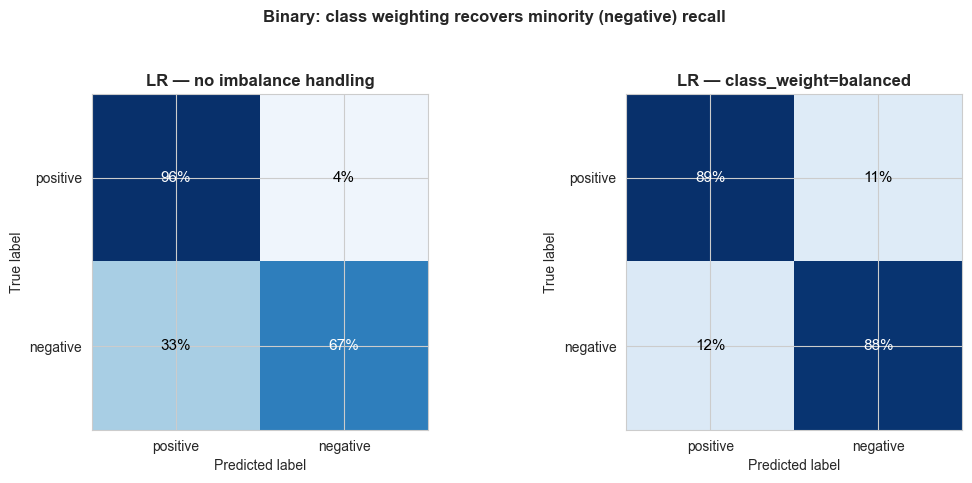

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
evaluation.plot_confusion_matrix(results_b['logreg']['confusion_matrix'], labels_b,
    'LR — no imbalance handling', ax=ax[0])
evaluation.plot_confusion_matrix(results_b['logreg_balanced']['confusion_matrix'], labels_b,
    'LR — class_weight=balanced', ax=ax[1])
plt.suptitle('Binary: class weighting recovers minority (negative) recall', fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_confusion_binary.png'); plt.show()

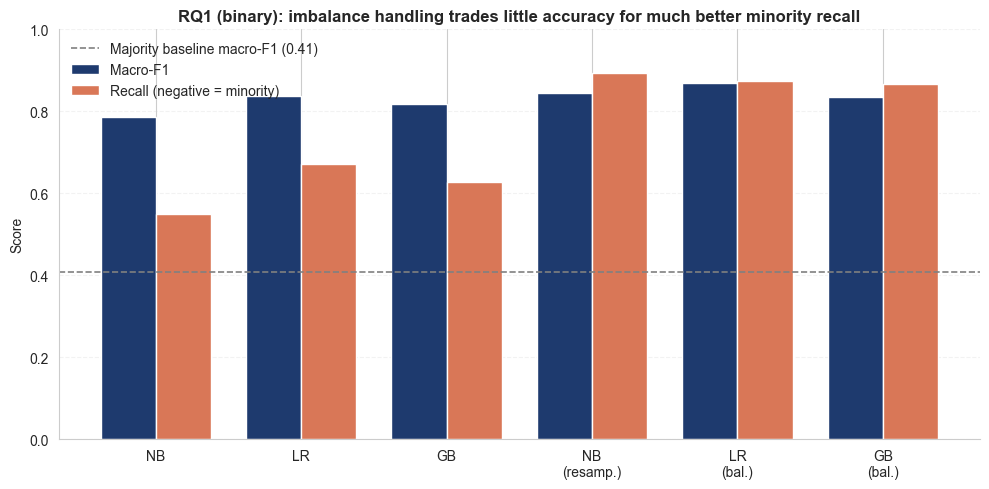

In [6]:
order = ['naive_bayes', 'logreg', 'gboost', 'naive_bayes_resampled', 'logreg_balanced', 'gboost_balanced']
disp  = ['NB', 'LR', 'GB', 'NB\n(resamp.)', 'LR\n(bal.)', 'GB\n(bal.)']
neg = labels_b.index('negative')
f1   = [results_b[k]['f1_macro'] for k in order]
rneg = [results_b[k]['recall_per_class'][neg] for k in order]
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, f1, w, label='Macro-F1', color=NAVY)
ax.bar(x + w/2, rneg, w, label='Recall (negative = minority)', color=ORANGE)
mb = results_b['majority_baseline']['f1_macro']
ax.axhline(mb, ls='--', color='gray', lw=1.2, label=f'Majority baseline macro-F1 ({mb:.2f})')
ax.set_xticks(x); ax.set_xticklabels(disp); ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('RQ1 (binary): imbalance handling trades little accuracy for much better minority recall', fontweight='bold')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_imbalance_comparison.png'); plt.show()

## 3. Ternary framing

Adds the 3★ neutral class — the minority, and the population RQ1 most wants to probe.

In [7]:
labels_t = ['positive', 'neutral', 'negative']
results_t, te_t, vec_t = run_all('ternary', 'sentiment_ternary', labels_t)
cmp_t = evaluation.compare_models(results_t)
cmp_t.to_csv(TABLES_DIR / 'rq1_ternary_comparison.csv')
evaluation.results_to_latex(cmp_t, TABLES_DIR / 'rq1_ternary_comparison.tex',
    caption='RQ1 model comparison, ternary framing.', label='tab:rq1_ternary')
cmp_t

[ternary] train 69,949 test 17,489 | {'positive': 51828, 'negative': 12601, 'neutral': 5520}


,accuracy,f1_macro,f1_weighted,recall_macro,recall_positive,recall_neutral,recall_negative
model,,,,,,,
majority_baseline,0.6394,0.2600,0.4988,0.3333,1.0000,0.0000,0.0000
naive_bayes,0.7801,0.5077,0.7405,0.5085,0.9701,0.0040,0.5514
logreg,0.8134,0.5866,0.7898,0.5739,0.9544,0.0865,0.6809
gboost,0.7989,0.5705,0.7731,0.5554,0.9571,0.0833,0.6257
naive_bayes_resampled,0.7136,0.5962,0.7524,0.6482,0.7423,0.4992,0.7032
logreg_balanced,0.7669,0.6248,0.7892,0.6544,0.8319,0.4231,0.7082
gboost_balanced,0.7329,0.6030,0.7652,0.6419,0.7816,0.4487,0.6953


**Reading.** This is where imbalance bites hardest. Without handling, Naive Bayes predicts the neutral class with **~0.4% recall** — a textbook minority-class collapse — and even Logistic Regression manages only ~9%. Balancing raises LR's neutral recall to ~0.43 and NB's (resampled) to ~0.51, but at a real accuracy cost (≈0.81 → ≈0.77). The 3★ class never becomes easy: these reviews genuinely mix positive and negative sentiment, which is precisely the limitation RQ1 set out to characterise and the motivation for the sentence-level view in RQ2.

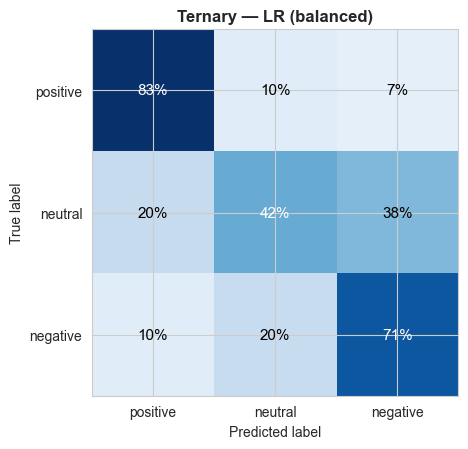

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
evaluation.plot_confusion_matrix(results_t['logreg_balanced']['confusion_matrix'], labels_t,
    'Ternary — LR (balanced)', ax=ax)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_confusion_ternary.png'); plt.show()

## 4. Feature representation: unigrams vs unigrams+bigrams

One of RQ1's sub-questions — do bigrams help, and is the larger feature space worth it?

In [9]:
tr_b, teb = dataset.prepare_task(train_df, test_df, 'sentiment_binary')
yb, yteb = tr_b['sentiment_binary'].values, teb['sentiment_binary'].values
rows = []
for fname, kw in features.FEATURE_CONFIGS.items():
    Xtr, Xte, _ = features.fit_transform_split(tr_b['clean_text'], teb['clean_text'],
                                               max_features=20000, min_df=5, **kw)
    m = models.get_logistic_regression(class_weight='balanced'); m.fit(Xtr, yb)
    r = evaluation.evaluate_model(yteb, m.predict(Xte), labels=labels_b)
    rows.append({'features': fname, 'n_features': Xtr.shape[1], 'accuracy': r['accuracy'],
                 'f1_macro': r['f1_macro'], 'recall_negative': r['recall_per_class'][labels_b.index('negative')]})
feat_cmp = pd.DataFrame(rows).set_index('features').round(4)
feat_cmp.to_csv(TABLES_DIR / 'rq1_feature_comparison.csv')
feat_cmp

,n_features,accuracy,f1_macro,recall_negative
features,,,,
tfidf_unigram,8838,0.8755,0.8607,0.8828
tfidf_uni_bigram,20000,0.8849,0.8698,0.8750


**Reading.** Adding bigrams roughly doubles the vocabulary (≈8.5K → 20K features) for a small but real macro-F1 gain. Bigrams capture negations and short phrases ("not worth", "highly recommend") that unigrams miss. The gain is modest, so for a strictly interpretability-first setup unigrams remain a defensible, leaner choice.

## 5. Interpretability (the main RQ)

A linear TF-IDF model is directly inspectable: each feature has a signed weight. This is the interpretability side of the performance/interpretability trade-off.

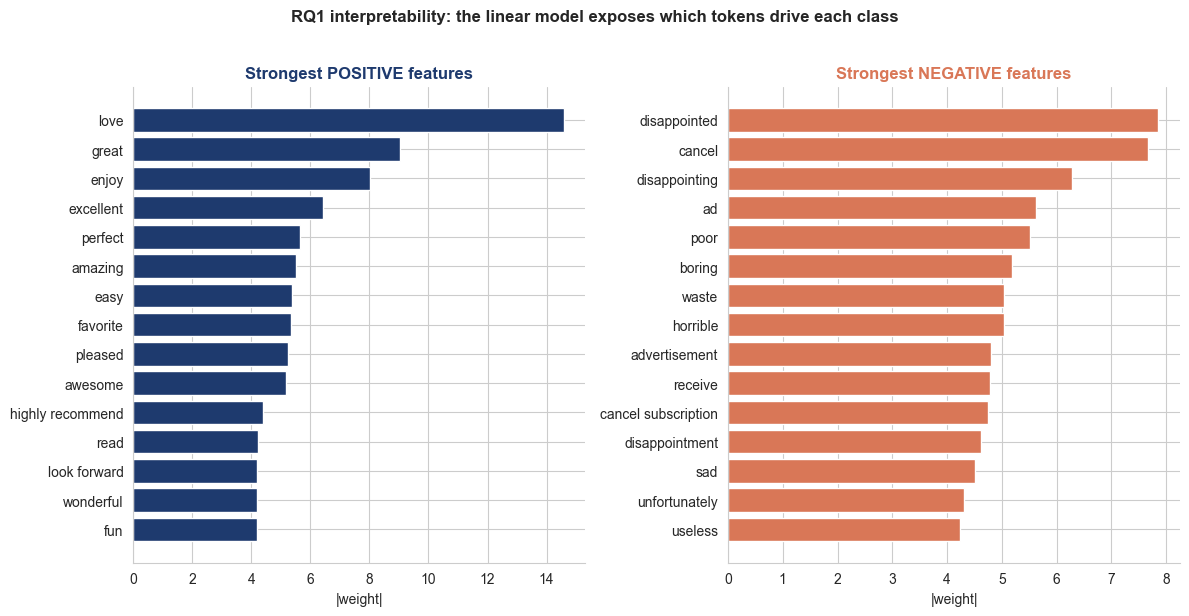

In [10]:
import pickle
Xtr, Xte, vec_final = features.fit_transform_split(tr_b['clean_text'], teb['clean_text'],
                                                  ngram_range=(1, 2), max_features=20000, min_df=5)
lr_final = models.get_logistic_regression(class_weight='balanced'); lr_final.fit(Xtr, yb)
feats = np.array(vec_final.get_feature_names_out()); coef = lr_final.coef_[0]
order_c = np.argsort(coef)
top_pos = [(feats[i], coef[i]) for i in order_c[-15:][::-1]]
top_neg = [(feats[i], coef[i]) for i in order_c[:15]]
pd.DataFrame({'word_positive': [w for w, _ in top_pos], 'coef_positive': [round(c, 3) for _, c in top_pos],
              'word_negative': [w for w, _ in top_neg], 'coef_negative': [round(c, 3) for _, c in top_neg]}
             ).to_csv(TABLES_DIR / 'rq1_lr_top_features.csv', index=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6))
a1.barh([w for w, _ in top_pos][::-1], [c for _, c in top_pos][::-1], color=NAVY)
a1.set_title('Strongest POSITIVE features', fontweight='bold', color=NAVY)
a2.barh([w for w, _ in top_neg][::-1], [-c for _, c in top_neg][::-1], color=ORANGE)
a2.set_title('Strongest NEGATIVE features', fontweight='bold', color=ORANGE)
for a in (a1, a2): a.set_xlabel('|weight|'); a.spines[['top', 'right']].set_visible(False)
plt.suptitle('RQ1 interpretability: the linear model exposes which tokens drive each class', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_lr_coefficients.png'); plt.show()

**Reading.** The positive weights (*love, great, excellent, perfect, favorite*) and negative weights (*cancel, disappoint, poor, waste, horrible*) are immediately sensible. Note that the single strongest negative token is **cancel** — a billing/renewal word, not a product-quality word. That directly anticipates RQ2: the biggest source of negativity in subscription products is the *billing* experience, and a transparent linear model surfaces it for free. This is the crux of the trade-off — Logistic Regression matches the gradient-boosted model here while remaining fully auditable.

## 6. Error analysis

The most confidently wrong predictions are the most informative failures.

In [11]:
proba, pred = lr_final.predict_proba(Xte), lr_final.predict(Xte)
hardest = evaluation.find_hardest_examples(teb['text'].reset_index(drop=True), yteb, pred, proba, n=25)
hardest['rating'] = teb['rating'].reset_index(drop=True).loc[hardest.index].values
hardest[['rating', 'y_true', 'y_pred', 'confidence', 'text']].to_csv(
    TABLES_DIR / 'rq1_error_analysis_binary.csv', index=False)
hardest[['rating', 'y_true', 'y_pred', 'confidence', 'text']].head(10)

,rating,y_true,y_pred,confidence,text
10753,5,positive,negative,0.999820,Very disappointed because only primetime listi...
14492,5,positive,negative,0.999482,I had to cancel this.
15722,4,positive,negative,0.998327,Waste of money
19,1,negative,positive,0.996843,Perfect
1603,5,positive,negative,0.996289,Not worth the money ad after ad overpriced items
11863,5,positive,negative,0.996079,Tried to cancel but not able!!! Thought I’d or...
777,5,positive,negative,0.996045,To many ads
8822,4,positive,negative,0.996045,Too many ads
2204,4,positive,negative,0.996045,Too many ads
2981,1,negative,positive,0.995986,I love this magazine.....and would love it eve...


**Reading.** The confident errors are dominated by genuinely hard cases — sarcasm, mixed reviews where one strong sentiment word dominates the bag-of-words signal, and reviews whose star rating arguably disagrees with their text. They are not systematic preprocessing failures, which is reassuring for the pipeline.

In [12]:
import pickle
pickle.dump(lr_final, open(MODELS_DIR / 'lr_binary.pkl', 'wb'))
pickle.dump(vec_final, open(MODELS_DIR / 'tfidf_binary.pkl', 'wb'))
print('Saved binary LR + TF-IDF vectoriser for the RQ2 robustness check.')

Saved binary LR + TF-IDF vectoriser for the RQ2 robustness check.


**RQ1 takeaways.**
- Accuracy is the wrong headline metric here; under imbalance it hides minority-class failure. Macro-F1 and per-class recall tell the real story.
- Imbalance handling (balanced weights / resampling) is essential and nearly free under the binary framing; under the ternary framing it forces a genuine accuracy-vs-minority-recall trade-off.
- **Performance vs interpretability:** Logistic Regression is as accurate as gradient boosting on these TF-IDF features *and* fully interpretable via its weights — the better choice when transparency matters. Gradient boosting adds complexity without a clear win here.
- The 3★ neutral class is the hard ceiling and motivates the sentence-level analysis in RQ2.